##### USING FROM .PY FILES

In [34]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
font = {'weight' : 'bold','size'   : 22}
mpl.rc('font', **font)
plt.rc('font',   size=209)  #set defaults so that the plots are readable
plt.rc('axes',   titlesize=20)
plt.rc('axes',   labelsize=20)
plt.rc('xtick',  labelsize=20)
plt.rc('ytick',  labelsize=20)
plt.rc('legend', fontsize =20)
plt.rc('figure', titlesize=20)
plt.rc('text',   usetex=True)
## FURTHER MATPLOTLIB FEATURES
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.markers import MarkerStyle
from matplotlib.transforms import Affine2D
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
#colors = ["#ffffcc", "#a1dab4", "#41b6c4", "#2c7fb8", "#253494"]
colors = ['#ff0000', "#41b6c4", '#0000ff']
my_cmap = ListedColormap(colors, name="my_cmap")
#############################################
## Alessandro edition
#############################################
#############################################
import os,sys,time
from copy import deepcopy as dcopy
import numpy as np
import healpy as hp

sys.path.insert(1, '/data/AMARINS/CMBWLxHI-CODES/scripts')
import cross_functions_theory      as cxft
import cross_functions_simulations as cxfs
###temp
#import cross_functions_simulations_2 as cxfs2
import handling_data               as hdata


import pymaster as nmt
del_l  = 20
nside  = 256
##############################
b    = nmt.NmtBin.from_nside_linear(nside, nlb=del_l)
leff = b.get_effective_ells()
feff = leff*(leff+1)/2/np.pi

In [47]:
#######
# GENERAL
#user   = 'amarins'
#######
# THEORETICAL
prefix = 'lowz_LSSTshearY10_bin1'
suffix = 'nch30_980_1260'
nside  = 256
seed_hi=9000
seed_k =9001
nsims  = 100
savefigs=0
savename ='_'.join(( prefix,suffix ))
pathsaveimgs = '/data/AMARINS/CMBWLxHI-CODES/images'

In [48]:
##########################################
## THEORETICAL
prefix = 'lowz_LSSTshearY10_bin1'
suffix = 'nch30_980_1260'
f1name = 'HI'
f2name = 'SHEAR'
gbin_used = 9
##########################################
## PATH to THEORECTICAL APS 
filepath_field1 = '/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f1}_cl_{}.txt'.format(prefix, suffix, f1=f1name)
filepath_field2 = '/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f2}_cl_{}.txt'.format(prefix, suffix, f2=f2name)
filepath_cross  = '/data/AMARINS/CMBWLxHI-DATA/theoretical/{}_{f1}x{f2}_cl_{}.txt'.format(prefix, suffix,f1=f1name, f2=f2name)  
##########################################
## LOADING DATA+
clf1 = np.loadtxt(filepath_field1).T
clf2 = np.loadtxt(filepath_field2).T
clcx = np.loadtxt(filepath_cross ).T
##
nch = int(clf1.shape[0])-1
##

In [11]:
generate_sims=0
if generate_sims:
    itime     = time.time()
    dict_sims = cxfs.dictionary_cross_simulations_quantities(clf1_dict_=clf1_dict, clf2_dict_=clf2_dict, clcx_dict_=clcx_dict, 
                                                             seed_k=seed_k, seed_hi=seed_hi, nsims=nsims,
                                                             show_time=False)
    nbins = dict_sims['sim0']['alm_hi_sim'].shape[0]
    l     = dict_sims['sim0']['l']
    print('Load/organize {0:d} sims: {1:.4f} seg'.format(nsims, time.time()-itime)) 

In [49]:
load_sims = True
project   = 'lowz_LSSTshearY10_bin1_nch30'#'bingo_nch30'#'bingo_nch10'#'bingo0'
path      = '/data/AMARINS/CMBWLxHI-DATA/simulations/{pr}'.format(pr=project)
varnames  = ['alm_hi_sim',  'alm_kappa_sim','cl_hi_sim', 'cl_hi_theory', 'cl_kappa_sim', 'cl_cross_sim','cl_cross_theory']
if load_sims:
    itime          = time.time()
    dict_sims      = cxfs.get_file_simulated_data(path, varnames, nsims_to_use=nsims)
    dict_sims_mean = cxfs.dict_averages_from_loaded_data(dict_all_=dict_sims, varnames_=varnames)
    nsims          = int(dict_sims_mean[varnames[0]]['bin1']['matrix'].shape[0]    )
    print('Load/organize {0:d} sims: {1:.4f} seg'.format(nsims, time.time()-itime)) 

Load/organize 4 sims: 6.5846 seg


In [28]:
ibin=0
cxfs.get_stat_from_sims_ibin(dict_sims=dict_sims, varname=varname, sim_name_standard='sim0', b_namaster=b, use_dl=1, ibin=ibin)

{'matrix': array([3.24508863e-06, 6.45429441e-06, 7.85095716e-06, 9.83145004e-06,
        9.77679223e-06, 9.71897880e-06, 9.87438267e-06, 1.02776532e-05,
        1.04723702e-05, 1.01748107e-05, 9.35836602e-06, 9.32021398e-06,
        9.08800287e-06, 9.32960995e-06, 9.23207761e-06, 8.47882336e-06,
        8.58970288e-06, 8.53597444e-06, 9.00212141e-06, 8.39654900e-06,
        8.36134470e-06, 8.50948920e-06, 8.12249579e-06, 7.52134123e-06,
        7.65185252e-06, 7.51430003e-06, 7.64042422e-06, 7.27383508e-06,
        7.33245821e-06, 7.13434246e-06, 6.98259805e-06, 7.10780262e-06,
        7.12551003e-06, 7.32760378e-06, 6.99219861e-06, 6.68548709e-06,
        6.64159057e-06, 6.65324332e-06]),
 'mean': array([2.29660703e-06, 6.56071271e-06, 8.49241284e-06, 9.30116169e-06,
        1.03608428e-05, 1.06973952e-05, 1.03807844e-05, 1.03046684e-05,
        9.96821489e-06, 9.89478819e-06, 9.87558998e-06, 9.30008978e-06,
        9.13461089e-06, 9.15391629e-06, 9.24695419e-06, 8.75395327e-06,
    

'/data/AMARINS/CMBWLxHI-CODES/images/lowz_LSSTshearY10_bin1_nch30_980_1260__cl_cross_sim_channels_together.png'

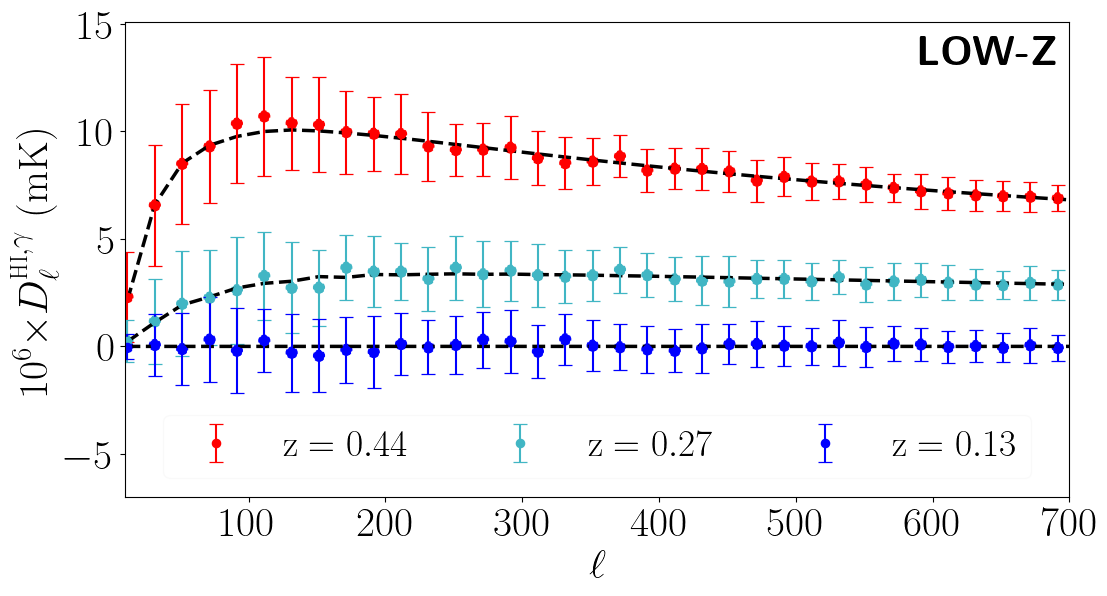

In [46]:
fig, ax  = plt.subplots(nrows=1, ncols=1)#, figsize=(14,6))
plt.subplots_adjust(top=1.1,right=1.6)
########################################################
N        = 3
zeff     = cxft.get_zeff(numin =980, numax =1260, nbands= nch, n_curves=N)['zeff']
ibins    = cxft.get_zeff(numin =980, numax =1260, nbands= nch, n_curves=N)['bins']
fact_exp = 6
fact     = 10**fact_exp
cmap     = plt.get_cmap(my_cmap, N+1)
varname  = 'cl_cross_sim'
###########################################################
for i, ibin in enumerate(ibins):
    dict_stat_sims_ibin = cxfs.get_stat_from_sims_ibin(dict_sims=dict_sims, varname=varname, sim_name_standard='sim0', b_namaster=b, use_dl=1, ibin=ibin)
    clcx_std = fact*dict_stat_sims_ibin['std']
    clcx_sim = fact*dict_stat_sims_ibin['mean']
    clcx_th  = fact*clcx[ibin+1] #clcx_th=[l, cl]; dim(clcx_th)=[nch+1, nl]
    ax.plot(    leff, feff*b.bin_cell(clcx_th), label = None, color='black',lw=2.5, ls='dashed')
    ax.scatter( leff, clcx_sim, marker='o', color=cmap(i), linestyle='dashed', s=60)
    ax.errorbar(leff, clcx_sim, yerr=1*clcx_std, 
                c=cmap(i),
                fmt='o', label=r'$\textrm{z} = '+str(zeff[i])+'$',
                markersize=6, capsize=5, markeredgewidth=0.9)
###########################################################
ax.set_yscale('linear'); ax.set_xscale('linear')
ax.set_ylabel(r'$10^{'+str(fact_exp)+'}$' + r'$ \times D_{\ell}^{\textrm{\LARGE{HI}},\tiny{\gamma}}\ (\textrm{mK})$ ', fontsize=30)
ax.set_xlabel(r'$\ell$ ', fontsize=30)
#ax.axhline(y=0, ls='dashed', color='lightgrey')

ax.set_xlim(10,700)   
ax.set_ylim(-7,15.1)   
ax.tick_params(axis='both', labelsize=30)
ax.text(x=650-60, y=13.1, s=r'$\textbf{LOW-Z}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
ax.legend(ncols=3, fontsize=27, loc='lower center',framealpha=0.1)
###########################################################
if type(suffix)!=type(None): pathname ="/data/AMARINS/CMBWLxHI-CODES/images/{}_{}__{}_{}.png".format(prefix, suffix, varname,"channels_together")
else:            pathname = "/data/AMARINS/CMBWLxHI-CODES/images/{}__{}_{}.png".format(prefix,varname,"channels_together")
#if savefigs: plt.savefig(pathname, dpi=100, bbox_inches='tight')
pathname

KeyError: 'l'

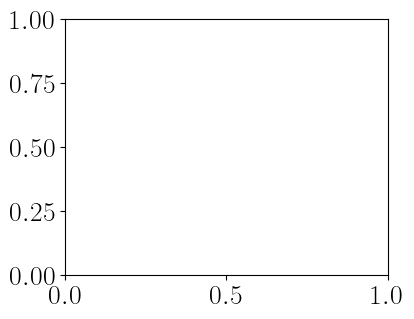

In [17]:
nrows,ncols = 2,2
fname = 'cl_cross_sim'
del_l  = 20
use_dl = True
##
clcx_dict = dcopy(dict_sims_mean['cl_cross_sim'])
nbins=30
yminlims = [-2.0e-7, -1.0e-7, -4e-8, -0.18e-7]#ska
ymaxlims = [+2.4e-7, +1.5e-7, +6e-8, +0.3e-7]#ska
#yminlims = [-0.6e-6, -0.37e-6, -2.8e-7, -0.18e-6]#bingo
#ymaxlims = [+1.0e-6, +0.5e-6, +3.8e-7, +0.28e-6]#bningo
#yminlims = [-2.5e-6, -1e-6, -4e-7, -0.18e-6]#fast
#ymaxlims = [+2.5e-6, +1.2e-6, +5e-7, +0.28e-6]#fast
fig  = plt.figure()
grid = plt.GridSpec(nrows, ncols, top=(20/30)*nrows, right=(20/30)*ncols,wspace=0.4, hspace=0.3)
##
ibins = np.linspace(0, nbins-1, int(ncols*nrows), dtype=np.int8)
g     = [[0,0],[0,1],[1,0],[1,1]]
##
for i, (ig,ibin) in enumerate(zip(g,ibins)):
    ax = plt.subplot(grid[ig[0],ig[1]])
    dict_sims_stat = cxfs.stat_simulations(dict_sims_=dict_sims, nside=nside, del_l=del_l, ich=ibin, use_dl=use_dl, include_leftover=True, show_time=False)
    l  = dict_sims_stat['l']
    l_ = np.arange(clcx_dict['l'].size)
    fact = l_*(l_+1)/2/np.pi if use_dl else 1
    ax.plot(      l_, fact*clcx_dict['bin{}'.format(ibin+1)], label = 'theory', color='black',lw=4)
    plt.errorbar( l, dict_sims_stat[fname]['mean'], yerr=dict_sims_stat[fname]['std'], 
                  fmt='o', color='orangered', linestyle='dashed', label = r'mean $\pm$ std', markersize=3, elinewidth=0.6)
    plt.fill_between(l, dict_sims_stat[fname]['mean'] - dict_sims_stat[fname]['std'], 
                        dict_sims_stat[fname]['mean'] + dict_sims_stat[fname]['std'],
                     color='darkgrey', alpha=0.5)
    ax.set_title(r'\textrm{Channel} '+r'${}$'.format(ibin+1))
    ax.set_yscale('log'); ax.set_xscale('log')
    _lmin_ = np.min(( l_.min(), l.min() ))+del_l
    _lmax_ = np.min(( l_.max(), l.max() ))
    ax.set_xlim(_lmin_,_lmax_)
    #ax.set_xlim(40,3*nside-1) 
    #ax.set_ylim(4e-6, 1e-4)
    if not i: plt.legend(loc='best', fontsize=17)
    if i in {0,2}:
        if use_dl: 
            ax.set_ylabel(r'$D_{\ell}(\kappa,{\LARGE \textrm{HI}})\ (\textrm{mK}^2)$ ', fontsize=20)
            if prefix=="bingo" :ax.set_ylim(4e-6, 1e-4)#ax.set_ylim(0.5e-10, 1e-7)
            elif prefix=='ska' :ax.set_ylim(1e-6,1.5e-4)
            elif prefix=='fast':pass#ax.set_ylim(1e-5, 4e-3)
            else: pass            
        else:      ax.set_ylabel(r'$C_{\ell}(\kappa,{\LARGE \textrm{HI}})\ (\textrm{mK}^2)$ ', fontsize=20)
    if i in {2,3}: ax.set_xlabel(r'$\ell$ ', fontsize=20)

if savefigs: plt.savefig(os.path.join(pathsaveimgs, '_'.join(( savename,'.'.join(('cls_cx_sims_channels_dell_{}'.format(int(del_l)),'png')) )) ), dpi=100, bbox_inches='tight' )

In [14]:
from matplotlib.ticker import ScalarFormatter
class ScalarFormatterClass(ScalarFormatter):
    def _set_format(self):
        self.format = "%1.2f"

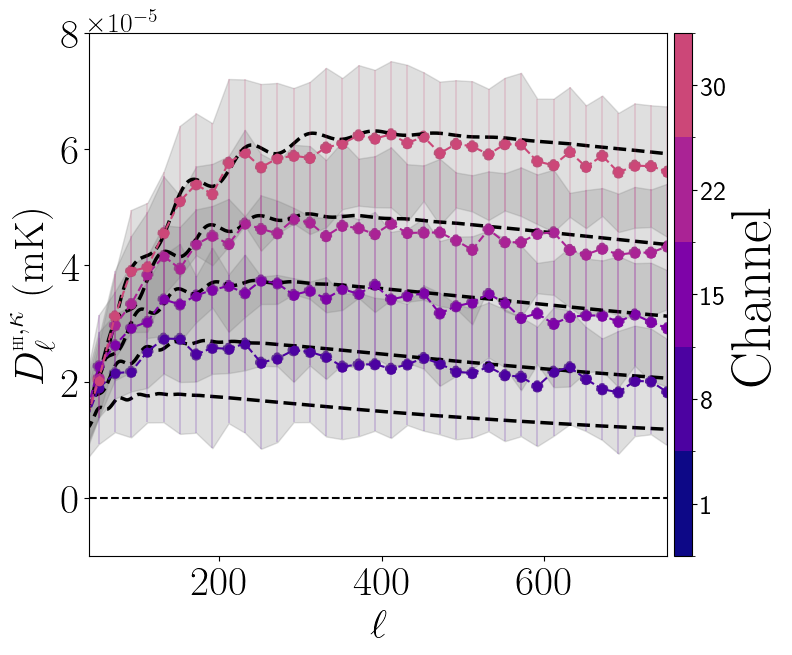

In [16]:
N=5
ibins = np.linspace(0, nbins-1, N, dtype=np.int8)
fname = 'cl_cross_sim'
del_l  = 20
use_dl = True

fig, ax  = plt.subplots(nrows=1, ncols=1)#, figsize=(14,6))
plt.subplots_adjust(top=1.2,right=1.2)
c    = np.arange(1., len(ibins) + 1)
cmap = plt.get_cmap("plasma", N+4)
norm = mpl.colors.BoundaryNorm(np.arange(len(c)+1)+0.5,len(c))
sm   = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([]) 

for i, ibin in enumerate(ibins):
    dict_sims_stat = cxfs.stat_simulations(dict_sims_=dict_sims, nside=nside, del_l=del_l, ich=ibin, use_dl=use_dl, include_leftover=True, show_time=False)
    l  = dict_sims_stat['l']
    l_ = np.arange(clcx_dict['l'].size)
    fact = l_*(l_+1)/2/np.pi if use_dl else 1
    ax.plot(l_, fact*clcx_dict['bin{}'.format(ibin+1)], label = 'theory', 
            color='black',lw=2.5, ls='dashed')
    ax.scatter(l, dict_sims_stat[fname]['mean'], marker='o', color=cmap(i), linestyle='dashed', s=60)
    ax.errorbar( l, dict_sims_stat[fname]['mean'], yerr=dict_sims_stat[fname]['std'], 
                 c=cmap(i), fmt='o', 
                 linestyle='dashed', label = r'mean $\pm$ std', markersize=6., elinewidth=0.24)
    plt.fill_between(l, dict_sims_stat[fname]['mean'] -dict_sims_stat[fname]['std'], 
                        dict_sims_stat[fname]['mean'] +dict_sims_stat[fname]['std'],
                     color='grey', alpha=0.25)
ax.set_yscale('linear'); ax.set_xscale('linear')

if use_dl: ax.set_ylabel(r'$D_{\ell}^{\textrm{\normalsize{HI}},\tiny{\kappa}}\ (\textrm{mK})$ ', fontsize=30)
else:      ax.set_ylabel(r'$C_{\ell}^{\textrm{\normalsize{HI}},\tiny{\kappa}}\ (\textrm{mK})$ ', fontsize=30)
ax.set_xlabel(r'$\ell$ ', fontsize=30)
ax.axhline(y=0, ls='dashed', color='black')
cbar = fig.colorbar(sm,ax=ax, ticks=c, pad=0.01, aspect=30, )
cbar.set_label(label=r'$\textrm{Channel}$',size=40)#,weight='bold')
cbar.ax.set_yticklabels(np.linspace(0, nbins-1, N, dtype=np.int8)+1)
_lmin_ = np.min(( l_.min(), l.min() ))+del_l+20
_lmax_ = np.min(( l_.max(), l.max() ))
ax.set_xlim(_lmin_,_lmax_)    
ax.set_ylim(-0.00001,0.00008)   
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.tick_params(axis='both', labelsize=30)
if 1: plt.savefig(os.path.join(pathsaveimgs, '_'.join(( savename,'.'.join(('cls_cx_sims_bingo_channels_together','png')) )) ), dpi=100, bbox_inches='tight' )

In [21]:
os.path.join(pathsaveimgs, '_'.join(( savename,'.'.join(('cls_cx_sims_bingo_channels_together','png')) )) )

'/data/AMARINS/CMBWLxHI-CODES/images/prototype_nch70_350_1050_cls_cx_sims_bingo_channels_together.png'

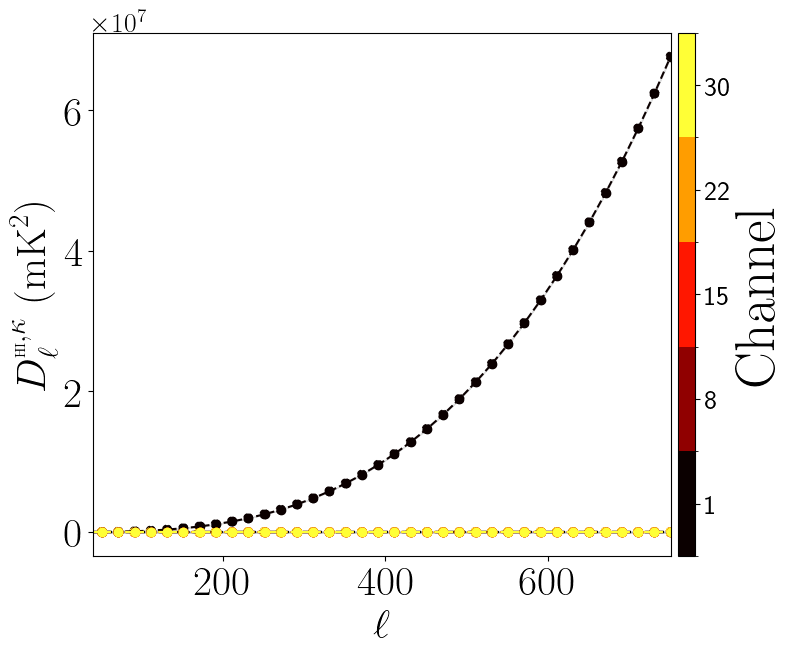

In [17]:
N=5
ibins = np.linspace(0, nbins-1, N, dtype=np.int8)
fname = 'cl_hi_sim'
del_l  = 20
use_dl = True

fig, ax  = plt.subplots(nrows=1, ncols=1)#, figsize=(14,6))
plt.subplots_adjust(top=1.2,right=1.2)
c    = np.arange(1., len(ibins) + 1)
cmap = plt.get_cmap("hot", N+1)
norm = mpl.colors.BoundaryNorm(np.arange(len(c)+1)+0.5,len(c))
sm   = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([]) 

for i, ibin in enumerate(ibins):
    dict_sims_stat = cxfs.stat_simulations(dict_sims_=dict_sims, nside=nside, del_l=del_l, ich=ibin, use_dl=use_dl, include_leftover=True, show_time=False)
    l  = dict_sims_stat['l']
    l_ = np.arange(clcx_dict['l'].size)
    fact = l_*(l_+1)/2/np.pi if use_dl else 1
    ax.plot(l_, fact*clf1_dict['bin{}'.format(ibin+1)], label = 'theory', 
            color='black',lw=1.5, ls='dashed')
    ax.scatter(l, dict_sims_stat[fname]['mean'], marker='o', color=cmap(i), linestyle='dashed', s=40)
    ax.errorbar( l, dict_sims_stat[fname]['mean'], yerr=dict_sims_stat[fname]['std'], 
                 c=cmap(i), fmt='o', 
                 linestyle='dashed', label = r'mean $\pm$ std', markersize=6., elinewidth=0.24)
    plt.fill_between(l, dict_sims_stat[fname]['mean'] -dict_sims_stat[fname]['std'], 
                        dict_sims_stat[fname]['mean'] +dict_sims_stat[fname]['std'],
                     color='grey', alpha=0.25)
ax.set_yscale('linear'); ax.set_xscale('linear')

if use_dl: ax.set_ylabel(r'$D_{\ell}^{\textrm{\normalsize{HI}},\tiny{\kappa}}\ (\textrm{mK}^2)$ ', fontsize=30)
else:      ax.set_ylabel(r'$C_{\ell}^{\textrm{\normalsize{HI}},\tiny{\kappa}}\ (\textrm{mK}^2)$ ', fontsize=30)
ax.set_xlabel(r'$\ell$ ', fontsize=30)
ax.axhline(y=0, ls='dashed', color='black')
cbar = fig.colorbar(sm,ax=ax, ticks=c, pad=0.01, aspect=30, )
cbar.set_label(label=r'$\textrm{Channel}$',size=40)#,weight='bold')
cbar.ax.set_yticklabels(np.linspace(0, nbins-1, N, dtype=np.int8)+1)
_lmin_ = np.min(( l_.min(), l.min() ))+del_l+20
_lmax_ = np.min(( l_.max(), l.max() ))
ax.set_xlim(_lmin_,_lmax_)    
ax.tick_params(axis='both', labelsize=30)
#ax.set_ylim(min(yminlims), max(ymaxlims))
if savefigs: plt.savefig(os.path.join(pathsaveimgs, '_'.join(( savename,'.'.join(('cls_hi_sims_channels_together','png')) )) ), dpi=100, bbox_inches='tight' )

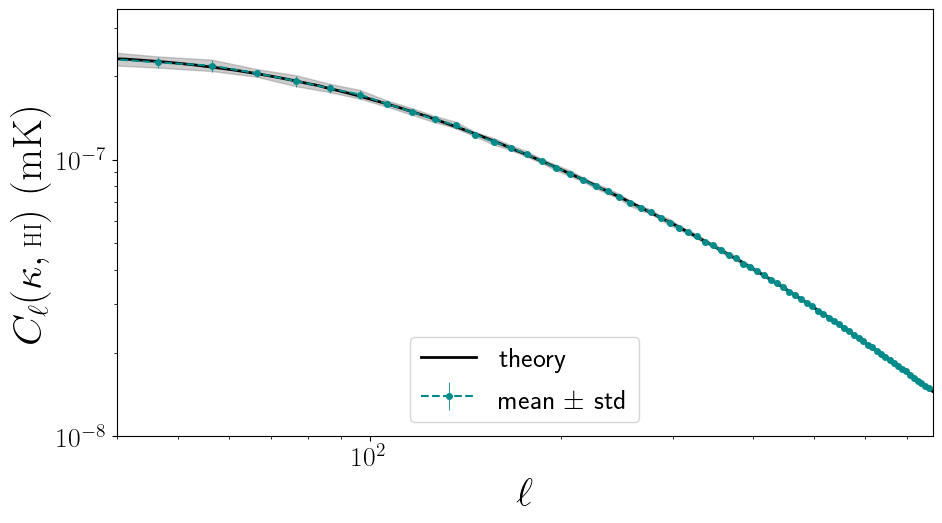

In [52]:
fig       = plt.figure()
grid      = plt.GridSpec(1,1,top=1.,right=1.4,wspace=0)
ax        = plt.subplot(grid[0,0])
l_ = np.arange(clf2_dict['bin1'].size)

#############################################
ibins = np.linspace(0, nbins-1, 4, dtype=np.int8)
fname = 'cl_kappa_sim'
l0     = 0
del_l  = 10
use_dl = False
fact   = 1
dict_sims_stat = cxfs.stat_simulations(dict_sims_=dict_sims, include_leftover=True, del_l=del_l, ich=ibin, use_dl=use_dl, show_time=False)
l = dict_sims_stat['l'] 
l_ = np.arange(clcx_dict['bin1'].size)
if use_dl: fact = l_*(l_+1)/2/np.pi
#############################################

ax.errorbar(    l, dict_sims_stat['cl_kappa_sim']['mean'], 
              yerr=dict_sims_stat['cl_kappa_sim']['std'], 
              fmt='o', color='darkcyan', linestyle='dashed', 
             label = r'mean $\pm$ std', markersize=4, elinewidth=0.6)
ax.fill_between(l, dict_sims_stat['cl_kappa_sim']['mean'] - dict_sims_stat['cl_kappa_sim']['std'], 
                   dict_sims_stat['cl_kappa_sim']['mean'] + dict_sims_stat['cl_kappa_sim']['std'],
                     color='grey', alpha=0.4)
ax.plot(l_, fact*clf2_dict['bin1'], label = 'theory', color='black' , lw=2)

ax.set_yscale('log'); ax.set_xscale('log')
ax.set_ylim(1e-8, 3.5e-7)
ax.set_xlim(40,767)
plt.legend(loc='lower center')
if use_dl: ax.set_ylabel(r'$D_{\ell}^{\kappa}$ ', fontsize=30)
else:      ax.set_ylabel(r'$C_{\ell}^{\kappa}$ ', fontsize=30)
ax.set_xlabel(r'$\ell$ ', fontsize=30)
if savefigs: plt.savefig(os.path.join(pathsaveimgs, '_'.join(( savename,'.'.join(('cls_kappa_sims_channels','png')) )) ), dpi=100, bbox_inches='tight' )

'/data/AMARINS/CMBWLxHI-CODES/images/prototype_nch70_350_1050_cls_cx_sims_channels_correlation kappa_diffchannels.png'

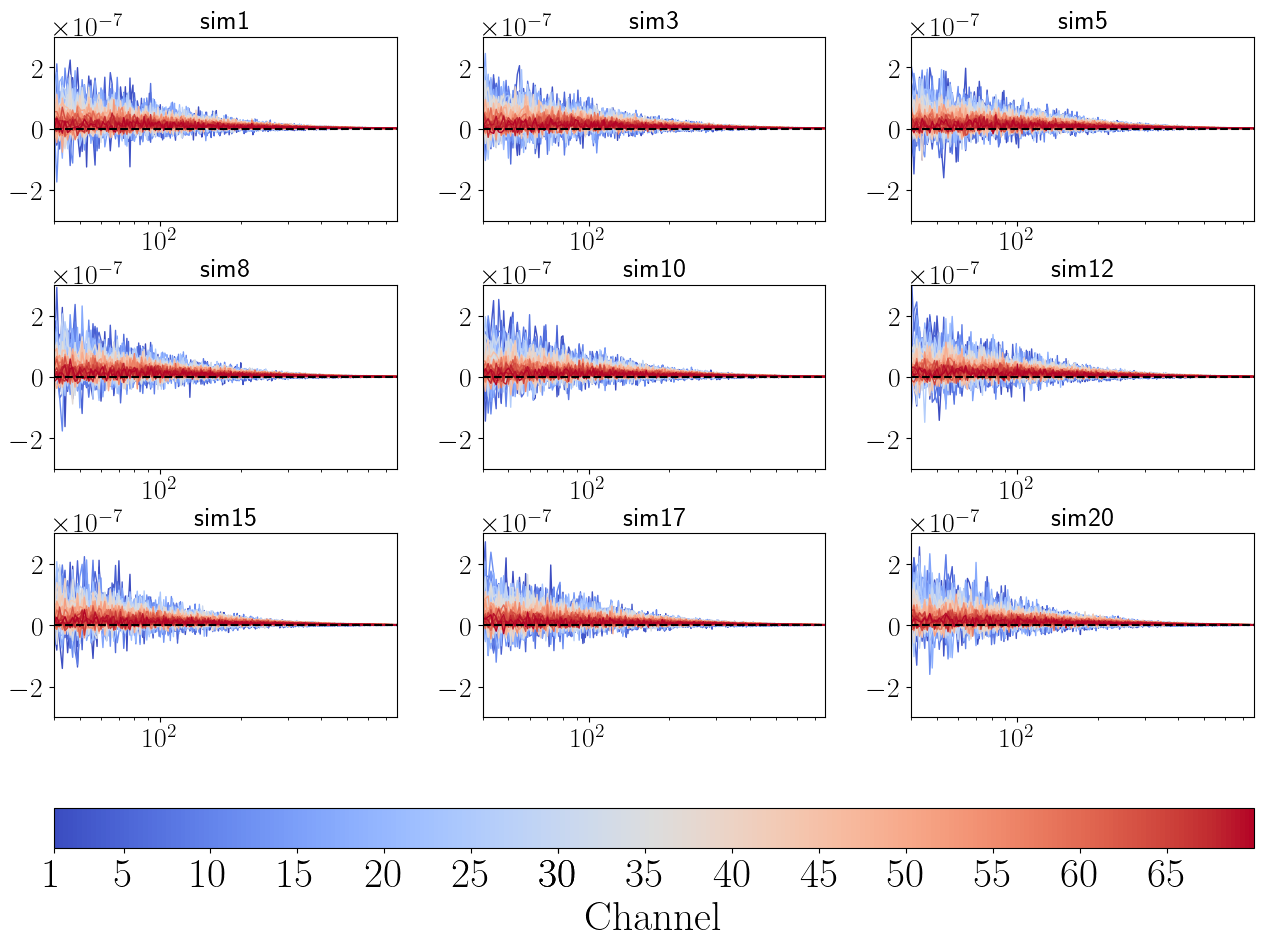

In [53]:
nbins      = dict_sims['sim0']['alm_hi_sim'].shape[0]
use_dl =0
ncols,nrows = 3,3
fig, axes   = plt.subplots(nrows=nrows, ncols=ncols)#, figsize=(20,14))
plt.subplots_adjust(top=2,right=2, wspace=0.25, hspace=0.35)

norm = mpl.colors.Normalize(vmin=1, vmax=int(nbins))
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.coolwarm)
cmap.set_array([])
nsims = len(dict_sims.keys())
jsims = ['sim{}'.format(i) for i in np.linspace(1, nsims-1, 9, dtype=np.int8)]

for j,(ax,jsim) in enumerate(zip(axes.flat,jsims)):
    alm_k_sim  = np.ascontiguousarray(dict_sims[jsim]['alm_kappa_sim']   )
    for i,ibin in enumerate(range(nbins)):
        alm_hi_sim_ibin = np.ascontiguousarray(dict_sims[jsim]['alm_hi_sim'][ibin])
        cl_cx_sim_ibin  = hp.alm2cl(alm_k_sim, alm_hi_sim_ibin)
        l_plot = np.arange(cl_cx_sim_ibin.size)
        fact = l_plot*(l_plot+1)/2/np.pi if use_dl else 1
        ax.plot(l_plot, fact*cl_cx_sim_ibin, color=cmap.to_rgba(i + 1), lw=1)
        ax.set_ylim(-3e-7, 3e-7)
        ax.set_xlim(40, 767)        
    ax.axhline(y=0, ls='dashed', color='black')
    ax.set_title(jsim)
    ax.set_xscale('log')
#ax.set_ylim(min(yminlims)-0.5e-6, max(ymaxlims)+0.5e-6)    
#ax.set_ylim(min(yminlims), max(ymaxlims))    
#c = np.arange(, nbins+10,10)

c = np.hstack(( [1],np.arange(5, nbins,5), [30] ))
cbar=fig.colorbar(cmap, ax=axes.ravel().tolist(),
                  orientation='horizontal',# extend="both",
                  pad=0.1, aspect=30, ticks=c)
cbar.set_label(label=r'$\textrm{Channel}$',size=30)#,weight='bold')
cbar.ax.tick_params(labelsize=30)
if savefigs:  plt.savefig(os.path.join(pathsaveimgs, '_'.join(( savename,'.'.join(('cls_cx_sims_channels_correlation kappa_diffchannels','png')) )) ), dpi=100, bbox_inches='tight' )
os.path.join(pathsaveimgs, '_'.join(( savename,'.'.join(('cls_cx_sims_channels_correlation kappa_diffchannels','png')) )) )

In [22]:
dict_sims['sim0'].keys()

dict_keys(['alm_kappa_sim', 'alm_hi_sim', 'alm_kappa_corr', 'alm_kappa_uncorr', 'cl_kappa_sim', 'cl_kappa_theory', 'cl_hi_sim', 'cl_hi_theory', 'cl_cross_sim', 'cl_cross_theory', 'l', 'seed_hi', 'seed_kunc'])

In [23]:
dict_sims['sim0']['alm_kappa_sim'].shape, dict_sims['sim0']['alm_hi_sim'].shape,

((295296,), (30, 295296))

In [26]:
dict_sims['sim0']['alm_kappa_uncorr'].shape, dict_sims['sim0']['alm_kappa_corr'].shape

((295296,), (30, 295296))

In [28]:
#ich=19
for jch in range(dict_sims['sim0']['alm_hi_sim'].shape[0]):
    
    alm_hi_sim    = dcopy(dict_sims['sim0']['alm_hi_sim'][jch,:])
    alm_kappa_sim = dcopy(dict_sims['sim0']['alm_kappa_sim'][:])
    alm_kappa_unc = dcopy(dict_sims['sim0']['alm_kappa_uncorr'][:])
    alm_kappa_cor = dcopy(dict_sims['sim0']['alm_kappa_corr'][jch, :])

    if not jch:
        Alm_hi_sim    = alm_hi_sim    
        Alm_kappa_sim = alm_kappa_sim    
        Alm_kappa_unc = alm_kappa_unc
        Alm_kappa_cor = alm_kappa_cor
    else:
        Alm_hi_sim    = np.vstack((Alm_hi_sim,    alm_hi_sim))
        Alm_kappa_sim = np.vstack((Alm_kappa_sim, alm_kappa_sim))
        Alm_kappa_unc = np.vstack((Alm_kappa_unc, alm_kappa_unc))
        Alm_kappa_cor = np.vstack((Alm_kappa_cor, alm_kappa_cor))   

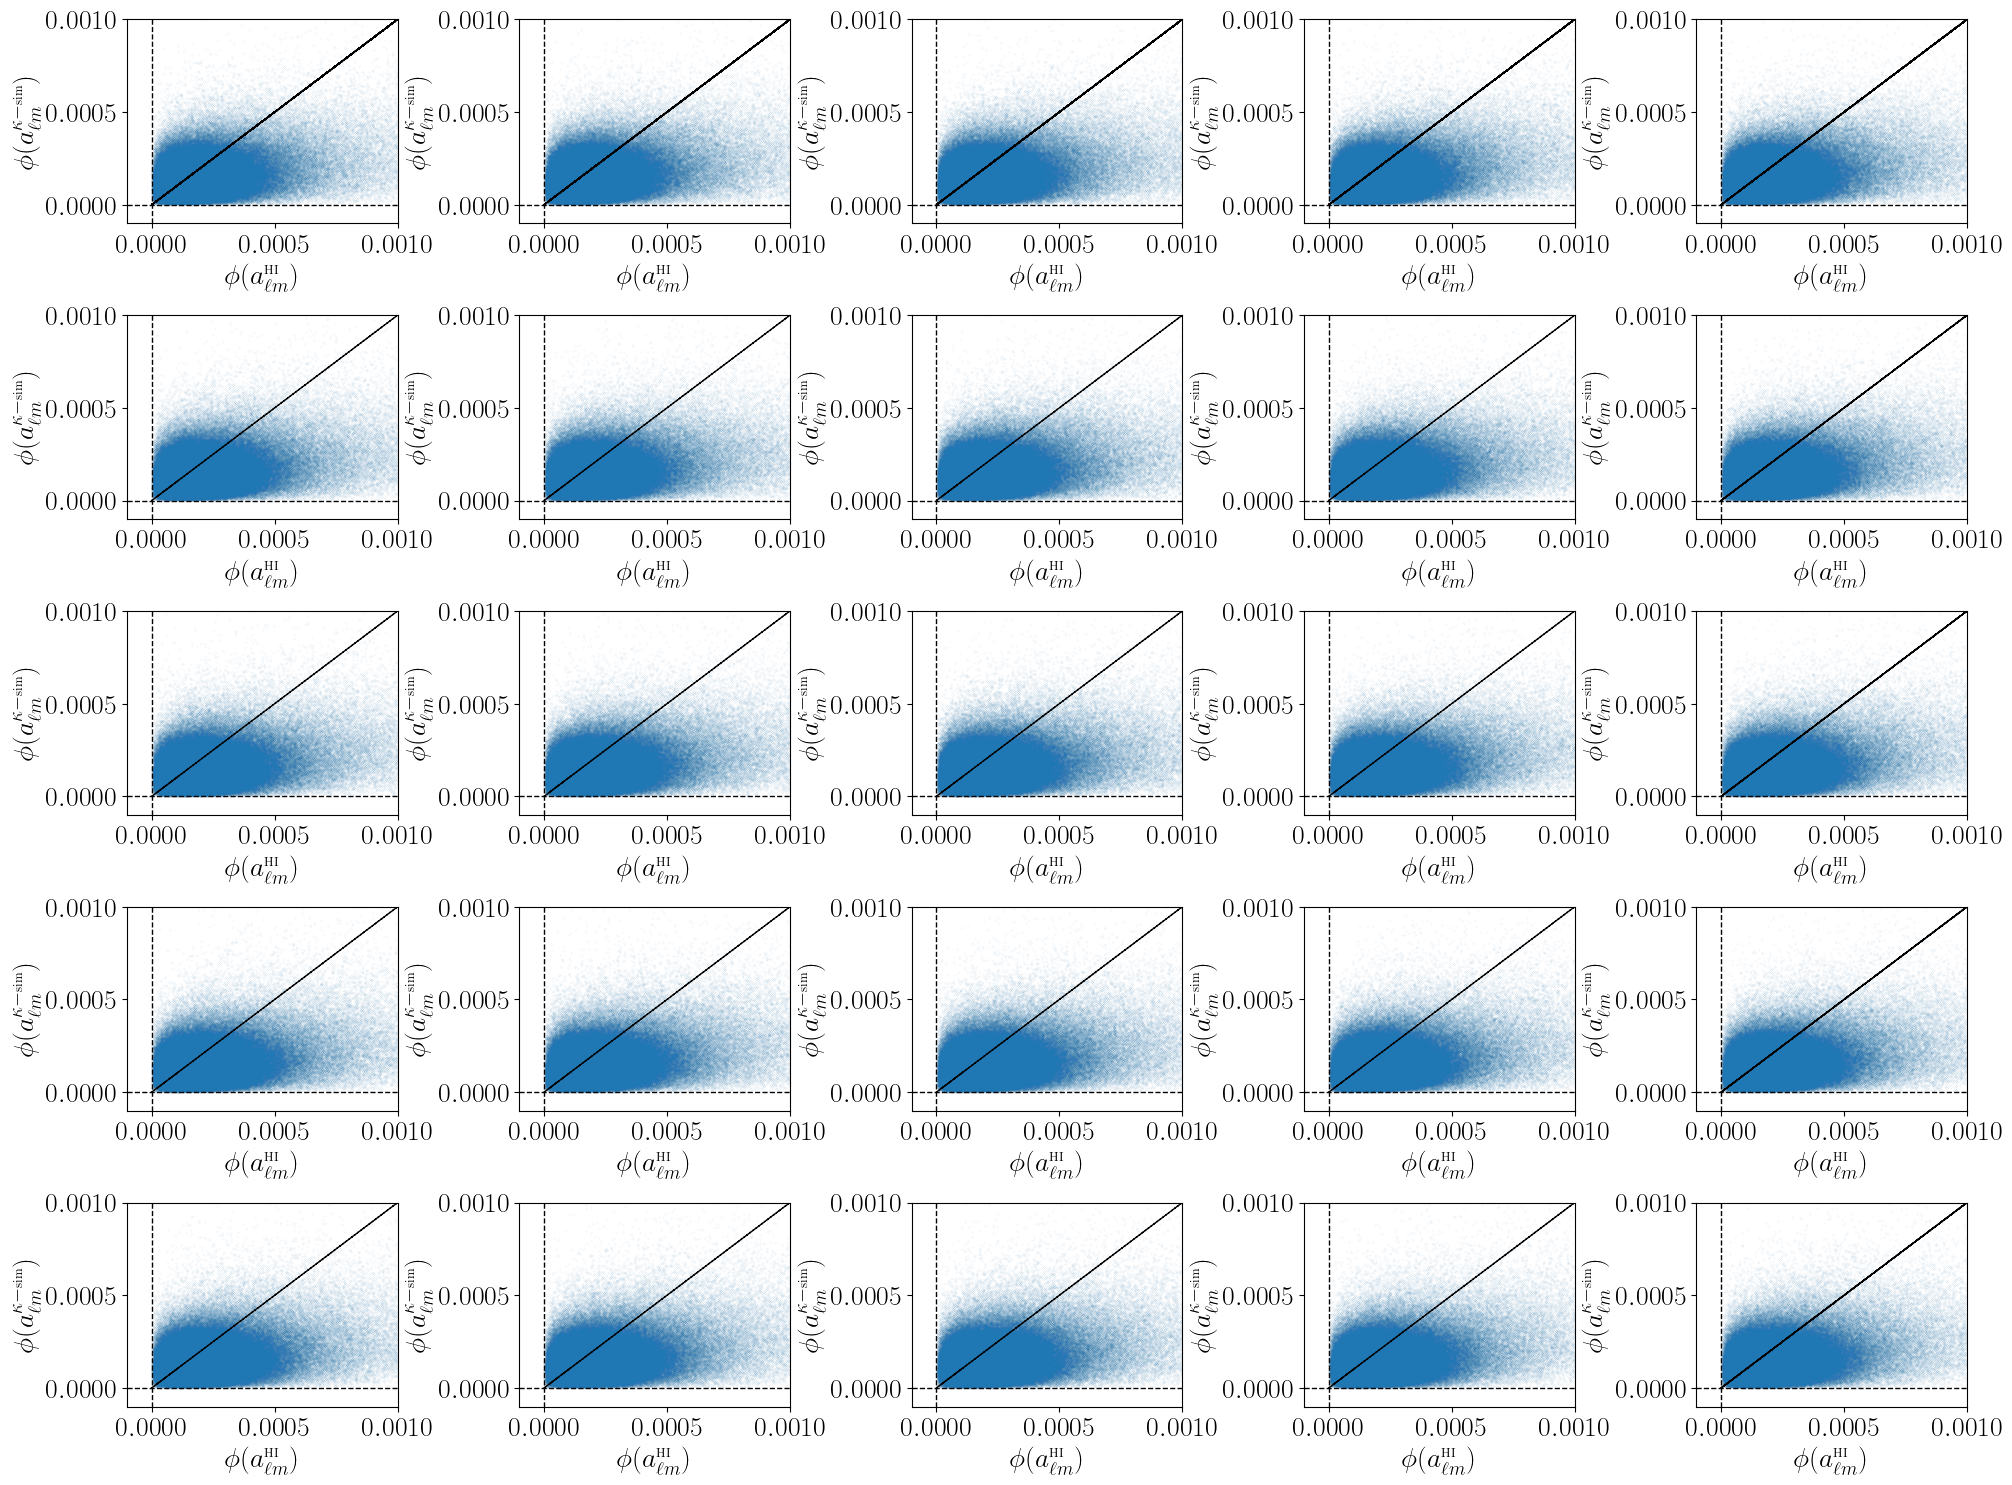

In [52]:
nrows, ncols = 5 , 5
fig   = plt.figure()
grid  = plt.GridSpec(nrows,ncols,top=3,right=3,hspace=0.45,wspace=0.45)
###############
ax     = plt.subplot(grid[0,0])
gy,gx = np.meshgrid(np.arange(nrows),np.arange(ncols))
gy,gx = gy.flatten(),gx.flatten()
bins  = np.linspace(0,nch-1,nrows*ncols, dtype=int)
for j, (jch,goy,gox) in enumerate(zip(bins, gy,gx)):
    ax = plt.subplot(grid[gox,goy])
    plt.scatter( np.abs(Alm_hi_sim[jch,:]), 
                 np.abs(Alm_kappa_sim[jch,:]),  s=0.001)
    plt.plot( np.abs(Alm_kappa_sim[jch,:]), 
              np.abs(Alm_kappa_sim[jch,:]),  ls='dashed',lw=1,c='black')
    plt.axvline(x=0, ls='dashed',lw=1, c='black')
    plt.axhline(y=0, ls='dashed',lw=1, c='black')
    plt.xlim(-0.0001, 0.001)
    plt.ylim(-0.0001, 0.001)
    ax.set_xlabel(r'$\phi (a^{\textrm{\small HI}}_{\ell m})$')
    ax.set_ylabel(r'$\phi (a^{\kappa-\textrm{\small sim}}_{\ell m})$')